In [ ]:
!pip install pandas scikit-learn torch transformers

In [ ]:
import pandas as pd
import torch.nn
import numpy as np
import pickle
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup, AdamW
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# load pre-trained tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3, output_attentions = False,
                                      output_hidden_states = False)
model = torch.nn.DataParallel(model, output_device=6)
model.to(device)

# load the data
train = pd.read_csv('/content/twitter_training.csv', encoding='utf-8', header=None)
test = pd.read_csv('/content/twitter_validation.csv', encoding='utf-8', header=None)

train = np.array(train)[:40000]
test = np.array(test)

train_data = train[(train[:,-2] == "Positive") | (train[:,-2] == "Negative")]
test_data = test[(test[:,-2] == "Positive") | (test[:,-2] == "Negative")]


x_train = train_data[:,-1]
y_train = [0 if label == 'Positive' else 1 for label in train_data[:,-2]]

x_test = test_data[:,-1]
y_test = [0 if label == 'Positive' else 1 for label in test_data[:,-2]]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip install matplotlib seaborn

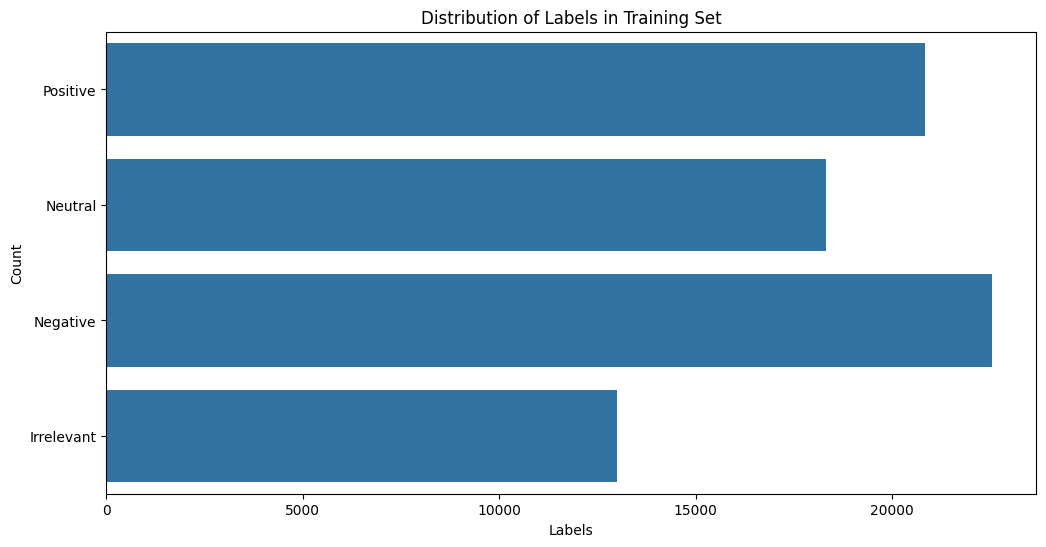

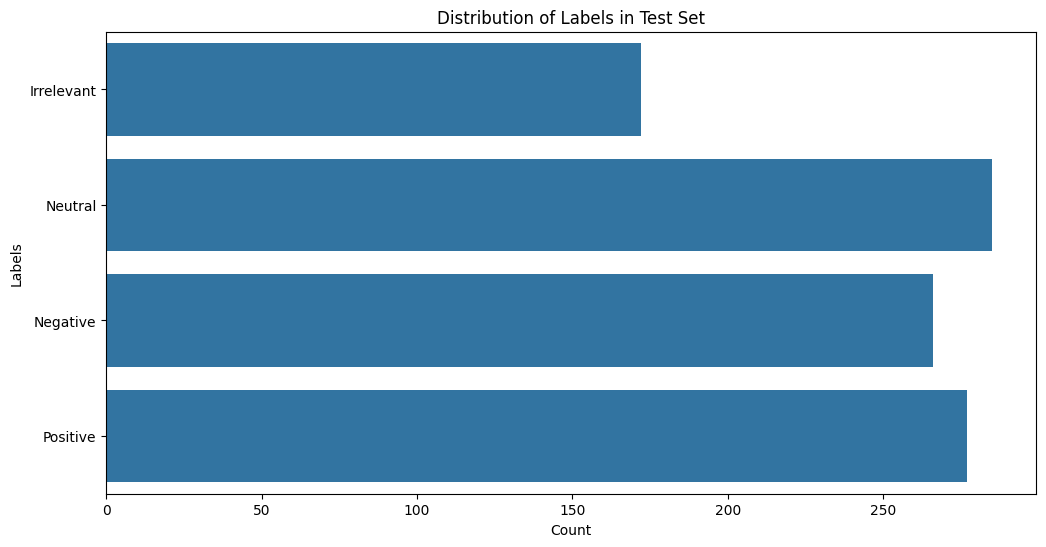

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# load the data
train = pd.read_csv('/content/twitter_training.csv', encoding='utf-8', header=None)
test = pd.read_csv('/content/twitter_validation.csv', encoding='utf-8', header=None)

# Assuming the labels are in the last column
train_labels = train.iloc[:, -2]
test_labels = test.iloc[:, -2]

# Plot the distribution of labels in the training set
plt.figure(figsize=(12, 6))
sns.countplot(train_labels)
plt.title('Distribution of Labels in Training Set')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

# Plot the distribution of labels in the test set
plt.figure(figsize=(12, 6))
sns.countplot(test_labels)
plt.title('Distribution of Labels in Test Set')
plt.xlabel('Count')
plt.ylabel('Labels')
plt.show()

In [ ]:
# Save the tokenizer to a file
with open('/content/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
x_train = [str(x) for x in x_train]
x_test = [str(x) for x in x_test]

In [ ]:
# Tokenize input sentences
x_train_encoded = tokenizer(x_train, padding=True, truncation=True, return_tensors="pt", pad_to_max_length=True, max_length=256)
x_test_encoded = tokenizer(x_test, padding=True, truncation=True, return_tensors="pt", pad_to_max_length=True, max_length=256)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2783: UserWarning: Though `pad_to_max_length` = `True`, it is ignored because `padding`=`True`.
  warnings.warn("Though `pad_to_max_length` = `True`, it is ignored because `padding`=`True`.")


In [ ]:
# Create DataLoader for train and test sets
train_dataset = TensorDataset(x_train_encoded["input_ids"], x_train_encoded["attention_mask"], torch.tensor(y_train))
test_dataset = TensorDataset(x_test_encoded["input_ids"], x_test_encoded["attention_mask"], torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, drop_last=True)

In [ ]:
# Fine-tune the model
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, eps = 1e-8)
# , momentum=0.9, weight_decay=0.09

In [ ]:
# Set up warm-up steps
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*2)

In [ ]:

for epoch in range(5):
    train_loss = 0
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids, attention_mask, labels = batch
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += outputs.loss.mean()
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss / len(train_loader):.4f}')
    # Evaluate on test set
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            test_loss += outputs.loss.mean().item()
            predicted_labels = torch.argmax(outputs.logits, dim=1)
            correct += (predicted_labels == labels).sum().item()
            total += len(labels)
        accuracy = correct/total
        print(f"Epoch {epoch+1}: Test Loss = {test_loss/len(test_loader):.4f}, Accuracy = {accuracy:.4f}")

Epoch 1, Loss: 0.0002
Epoch 1: Test Loss = 0.2327, Accuracy = 0.9223
Epoch 2, Loss: 0.0000
Epoch 2: Test Loss = 0.2752, Accuracy = 0.9299
Epoch 3, Loss: 0.0001
Epoch 3: Test Loss = 0.3077, Accuracy = 0.9356
Epoch 4, Loss: 0.0001
Epoch 4: Test Loss = 0.2913, Accuracy = 0.9337
Epoch 5, Loss: 0.0000
Epoch 5: Test Loss = 0.3690, Accuracy = 0.9280


In [ ]:
outputs.loss.mean().item()

In [ ]:
def predict_sentiments(text):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()
    # print(prediction)
    return ['Negative', 'Neutral', 'Positive'][prediction]

In [ ]:
predict_sentiments("bad")

'Neutral'

In [ ]:
# Assuming you have a trained model object named 'model'
with open('/content/model.pkl', 'wb') as file:
    pickle.dump(model, file)